# 2026 Biomedical Hackathon

Here is the code for the hackathon

In [9]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [11]:
# For Mac to hide output do Cmd+Shift+H
#!pip install "numpy<2" 
#!pip install scipy==1.11.4 
#!pip install  scanpy==1.12.3
!pip install matplotlib==3.11.1
!pip install squidpy



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq 
import anndata as ad
import seaborn as sns 
import sklearn

#np.random.seed(265)

/root/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
!pip install scvi-tools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.2/711.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [17]:
#import scvi
from scvi.model import SCANVI
# IF RUN INTO ISSUES WITH SCANVI, RESTART KERNEL!!!

# if want to use SCANVI, you need to do scvi.model.SCANVI instead

# scANVI (single-cell ANnotation using Variational Inference) is a semi-supervised 
# deep learning model in scvi-tools used for single-cell transcriptomics data

# This is the beginning of the actual code

In [37]:
adata_train_cell2

NameError: name 'adata_train_cell2' is not defined

In [19]:

counts_train = pd.read_csv('counts_train.csv', index_col=0)
counts_test  = pd.read_csv('counts_test.csv',  index_col=0)
meta_train   = pd.read_csv('meta_train.csv',   index_col=0)
meta_test    = pd.read_csv('meta_test.csv',    index_col=0)
for df in (counts_train, counts_test, meta_train, meta_test):
    df.index = df.index.astype(str)
    df.index.name = 'Cell_ID'

print('counts_train:', counts_train.shape)
print('counts_test :', counts_test.shape)
print('meta_train  :', meta_train.shape)
print('meta_test   :', meta_test.shape)

counts_train: (5000, 200)
counts_test : (5000, 200)
meta_train  : (5000, 12)
meta_test   : (5000, 12)


In [21]:
print('train label NA fraction:', meta_train['MERFISH_cell_type_annotation'].isna().mean())
print('test  label NA fraction:', meta_test['MERFISH_cell_type_annotation'].isna().mean())

meta_test[['volume', 'center_x', 'center_y', 'MERFISH_cell_type_annotation',
           'Region', 'Excitatory_vs_Inhibitory']].head()

train label NA fraction: 0.0
test  label NA fraction: 1.0


,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory
Cell_ID,,,,,,
2796212800954100068,3647.375000,9979.925856,8091.551222,NaN,1.0,excitatory
2707604000123100074,1100.773071,5385.479527,9654.331573,NaN,NaN,NaN
2796212800080100088,3029.895508,7193.083494,550.081350,NaN,NaN,NaN
2946331700000000970,3262.542236,8948.681067,309.374372,NaN,NaN,NaN
2796212800882100299,1551.463623,7788.225136,7682.970213,NaN,1.0,inhibitory


In [95]:
# Paulete
'''
"SCANPY MODEL FOR GENE EXPRESSION"

#import scanpy as sc
import pandas as pd
import numpy as np


counts_train  = sc.read_csv('counts_test.csv') # read in count training with scanpy
meta_train   = pd.read_csv('meta_train.csv') # read in meta training with pandas

counts_train.obs = meta_train # attatch meta data to an object that contains count data

# 1) compute QC matrices

counts_train.obs['total_counts'] = counts_train.X.sum(axis=1) # total counts= sum of all transcripts detected in cells
counts_train.obs['n_genes'] = (counts_train.X > 0).sum(axis=1) # number of genes with atleast one transcript

# 2) filter low quality cells (remove debris, failed cells, and noise)

sc.pp.filter_cells(counts_train, min_counts=20) # remove cells that don't have enough RNA transcripts to be real
sc.pp.filter_cells(counts_train, min_genes=3) # remove cells that express almost nothing
#sc.pp = scanpy.preprocessing module

# 3) normalize data (standard log1p normalization)

sc.pp.normalize_total(counts_train, target_sum=1e4)
sc.pp.log1p(counts_train)

# 4) run PCA (principle component analysis compresses the data)
sc.pp.pca(counts_train)

# 5) build neighbor graph (needed for the cell clustering algorithm)


sc.pp.neighbors(counts_train)
#sc.pp.neighbors(counts_train, n_neighbors = 15, n_pcs = 30)
# I would change counts_train to use adata since it is pretty standard for 
# spatial transcriptomics.add_arguments

# 6) cluster the cells

# sc.tl.leiden() runs the Leiden clsutering algorithm
# this groups by optimizes modulatrity on nearest k-neighbor from heighbor graph
sc.tl.leiden(counts_train, resolution=0.5)
counts_train.obs['leiden']

# 7) identify marker genes

# sc.tl.rank_gene_groups() compares leiden clusters against each other
# genes that are highly expressed against other genes become our marker genes
sc.tl.rank_genes_groups(counts_train, 'leiden', method='wilcoxon') # Will plug into Sofia's code

# visualize the marker genes

sc.pl.rank_genes_groups(counts_train, n_genes=20) # Will plug into Sofia's code

# [0-4] vs rest represents cluster 0/1/2/3/4 vs rest of the clusters
# y axis is the ranking score from the differential expression test (wilxocen) FOR THAT CLUSTER
# the x axis is gene index in the ranking list across the clusters; doesn't mean anything other than index
'''

'\n"SCANPY MODEL FOR GENE EXPRESSION"\n\n#import scanpy as sc\nimport pandas as pd\nimport numpy as np\n\n\ncounts_train  = sc.read_csv(\'counts_test.csv\') # read in count training with scanpy\nmeta_train   = pd.read_csv(\'meta_train.csv\') # read in meta training with pandas\n\ncounts_train.obs = meta_train # attatch meta data to an object that contains count data\n\n# 1) compute QC matrices\n\ncounts_train.obs[\'total_counts\'] = counts_train.X.sum(axis=1) # total counts= sum of all transcripts detected in cells\ncounts_train.obs[\'n_genes\'] = (counts_train.X > 0).sum(axis=1) # number of genes with atleast one transcript\n\n# 2) filter low quality cells (remove debris, failed cells, and noise)\n\nsc.pp.filter_cells(counts_train, min_counts=20) # remove cells that don\'t have enough RNA transcripts to be real\nsc.pp.filter_cells(counts_train, min_genes=3) # remove cells that express almost nothing\n#sc.pp = scanpy.preprocessing module\n\n# 3) normalize data (standard log1p normaliza

### Sofia Workspace: 

<Axes: title={'center': 'Unique Transcripts per cell'}, xlabel='n_genes_by_counts', ylabel='Count'>

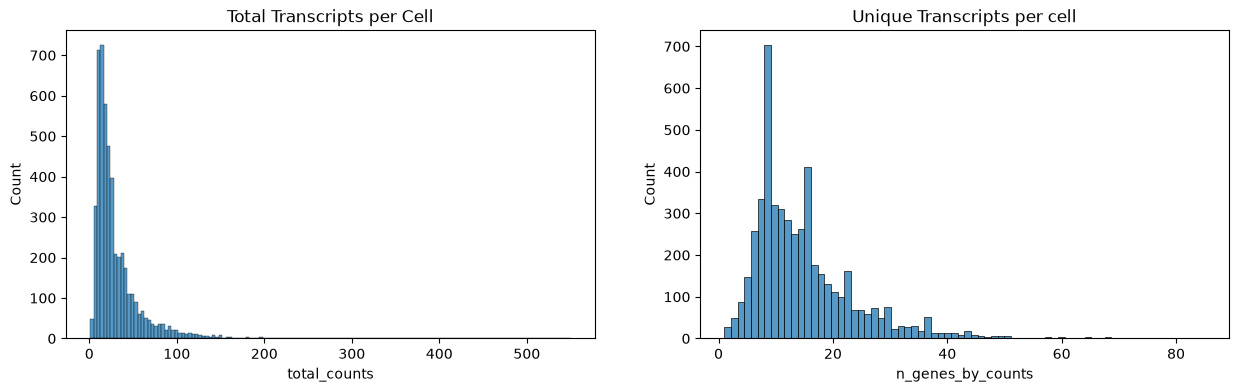

In [23]:
'''Squidpy Processing '''


adata_train = sq.read.vizgen(path = "." ,counts_file = 'counts_train.csv', meta_file = 'meta_train.csv') # reads files from 

sc.pp.calculate_qc_metrics(adata_train, percent_top= None, inplace=True, log1p=True)

fig, (axs1,axs2) = plt.subplots(1,2, figsize=(15,4))
axs1.set_title("Total Transcripts per Cell")
sns.histplot(adata_train.obs["total_counts"],kde = False, ax = axs1)

axs2.set_title("Unique Transcripts per cell")
sns.histplot(adata_train.obs["n_genes_by_counts"],kde = False, ax = axs2)


/tmp/ipykernel_125/395838934.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_train,resolution = 0.5) # cluster the cells into subgroups


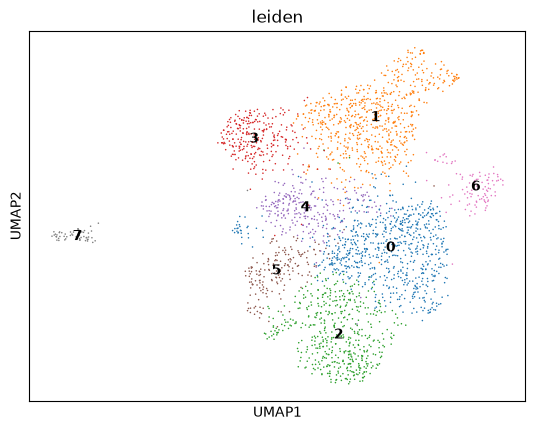

'#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly \nsq.gr.spatial_neighbors(adata_train, coord_type="generic", spatial_key="spatial2d")\nsq.gr.nhood_enrichment(adata_train, cluster_key="Cell_class")\nsq.pl.nhood_enrichment(\n    adata_train, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100\n)\n\n# spatial variability of gene expression \n# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression\n#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.\n\n'

In [25]:
'SCANPY + SQUIDPY MODEL FOR SPATIAL MAPPING'

# fixing up the data 

#filter the cells 
sc.pp.filter_cells(adata_train, min_counts=20) 
# can also use min_genes=200

sc.pp.normalize_total(adata_train,inplace = True) # normalize counts per cell 
sc.pp.log1p(adata_train) # log
sc.pp.pca(adata_train) #pca analysis 
sc.pp.neighbors(adata_train) # computer neighborhood graph 
sc.tl.umap(adata_train) #embed the neighborhood graph of the data 
sc.tl.leiden(adata_train,resolution = 0.5) # cluster the cells into subgroups 

sc.pl.umap(adata_train,color= "leiden",legend_loc='on data',size = 5,wspace = 0.4)



'''#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly 
sq.gr.spatial_neighbors(adata_train, coord_type="generic", spatial_key="spatial2d")
sq.gr.nhood_enrichment(adata_train, cluster_key="Cell_class")
sq.pl.nhood_enrichment(
    adata_train, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100
)

# spatial variability of gene expression 
# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression
#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.

'''

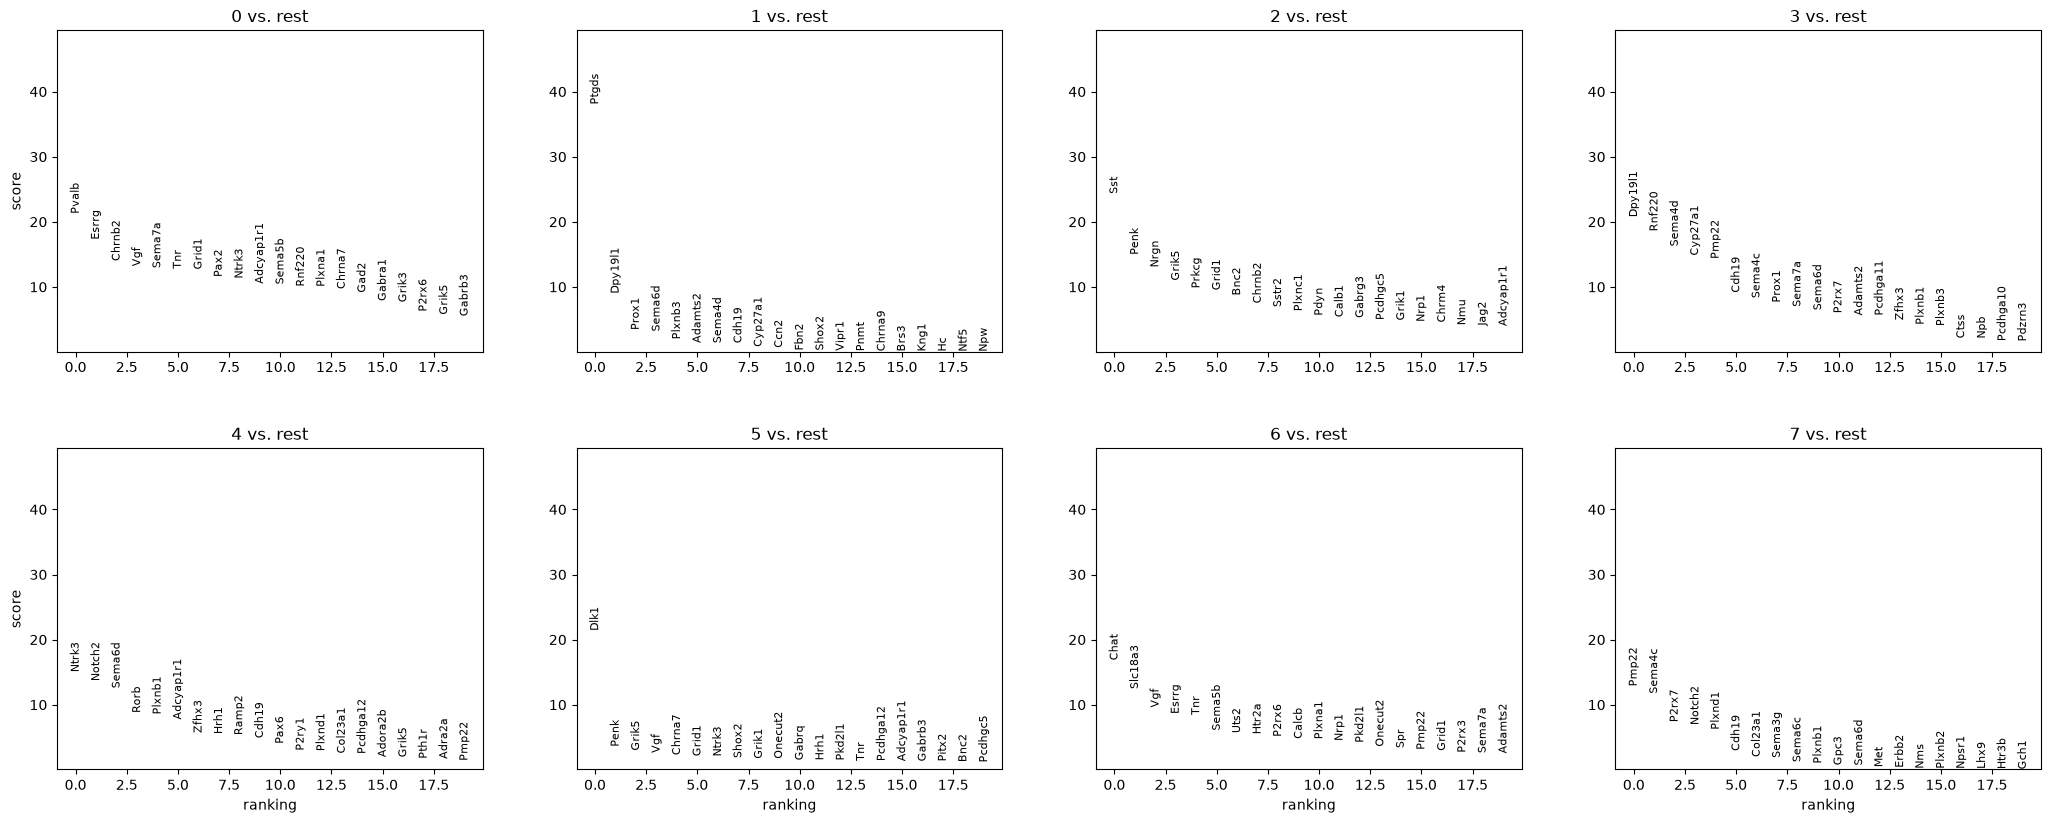

In [27]:
'GENE EXPRESSION RANKING GRAPP USING LEIDEN -Paulete' 

sc.tl.rank_genes_groups(adata_train, 'leiden', method='wilcoxon') # ranking
sc.pl.rank_genes_groups(adata_train, n_genes=20) # plot ranking


In [174]:
"Celltypist Classifications Based on Whole Mouse Brain Rerence Data -Paulete"

import celltypist
pred = celltypist.annotate(adata_train, model='Mouse_Whole_Brain.pkl', majority_voting=True)
print(pred.predicted_labels)

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 2733 cells and 200 genes
🔗 Matching reference genes in the model
🧬 131 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
                                 predicted_labels over_clustering  \
2707604700067100081        307 RO-RPA Pkd2l1 Gaba               0   
2787445900053200043  245 SPVI-SPVC Tlx3 Ebf3 Glut               3   
2795103300233100096        307 RO-RPA Pkd2l1 Gaba               2   
2787445900753100213         155 PRC-PAG Pax6 Glut               5   
2787889600412100201                  053 Sst Gaba               6   
...                                     

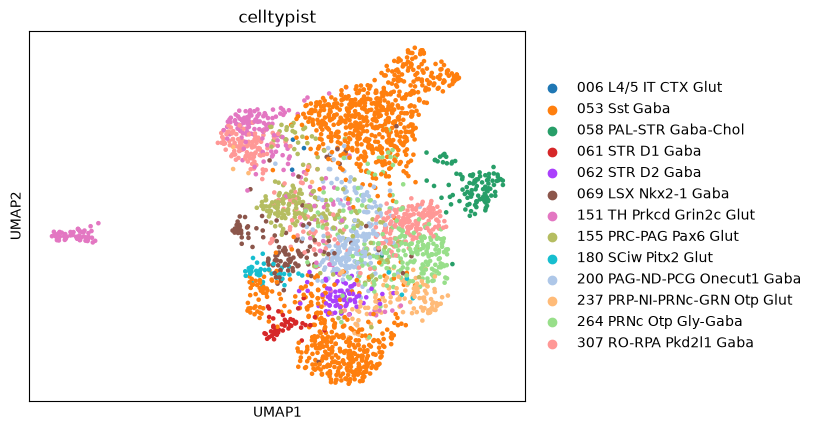

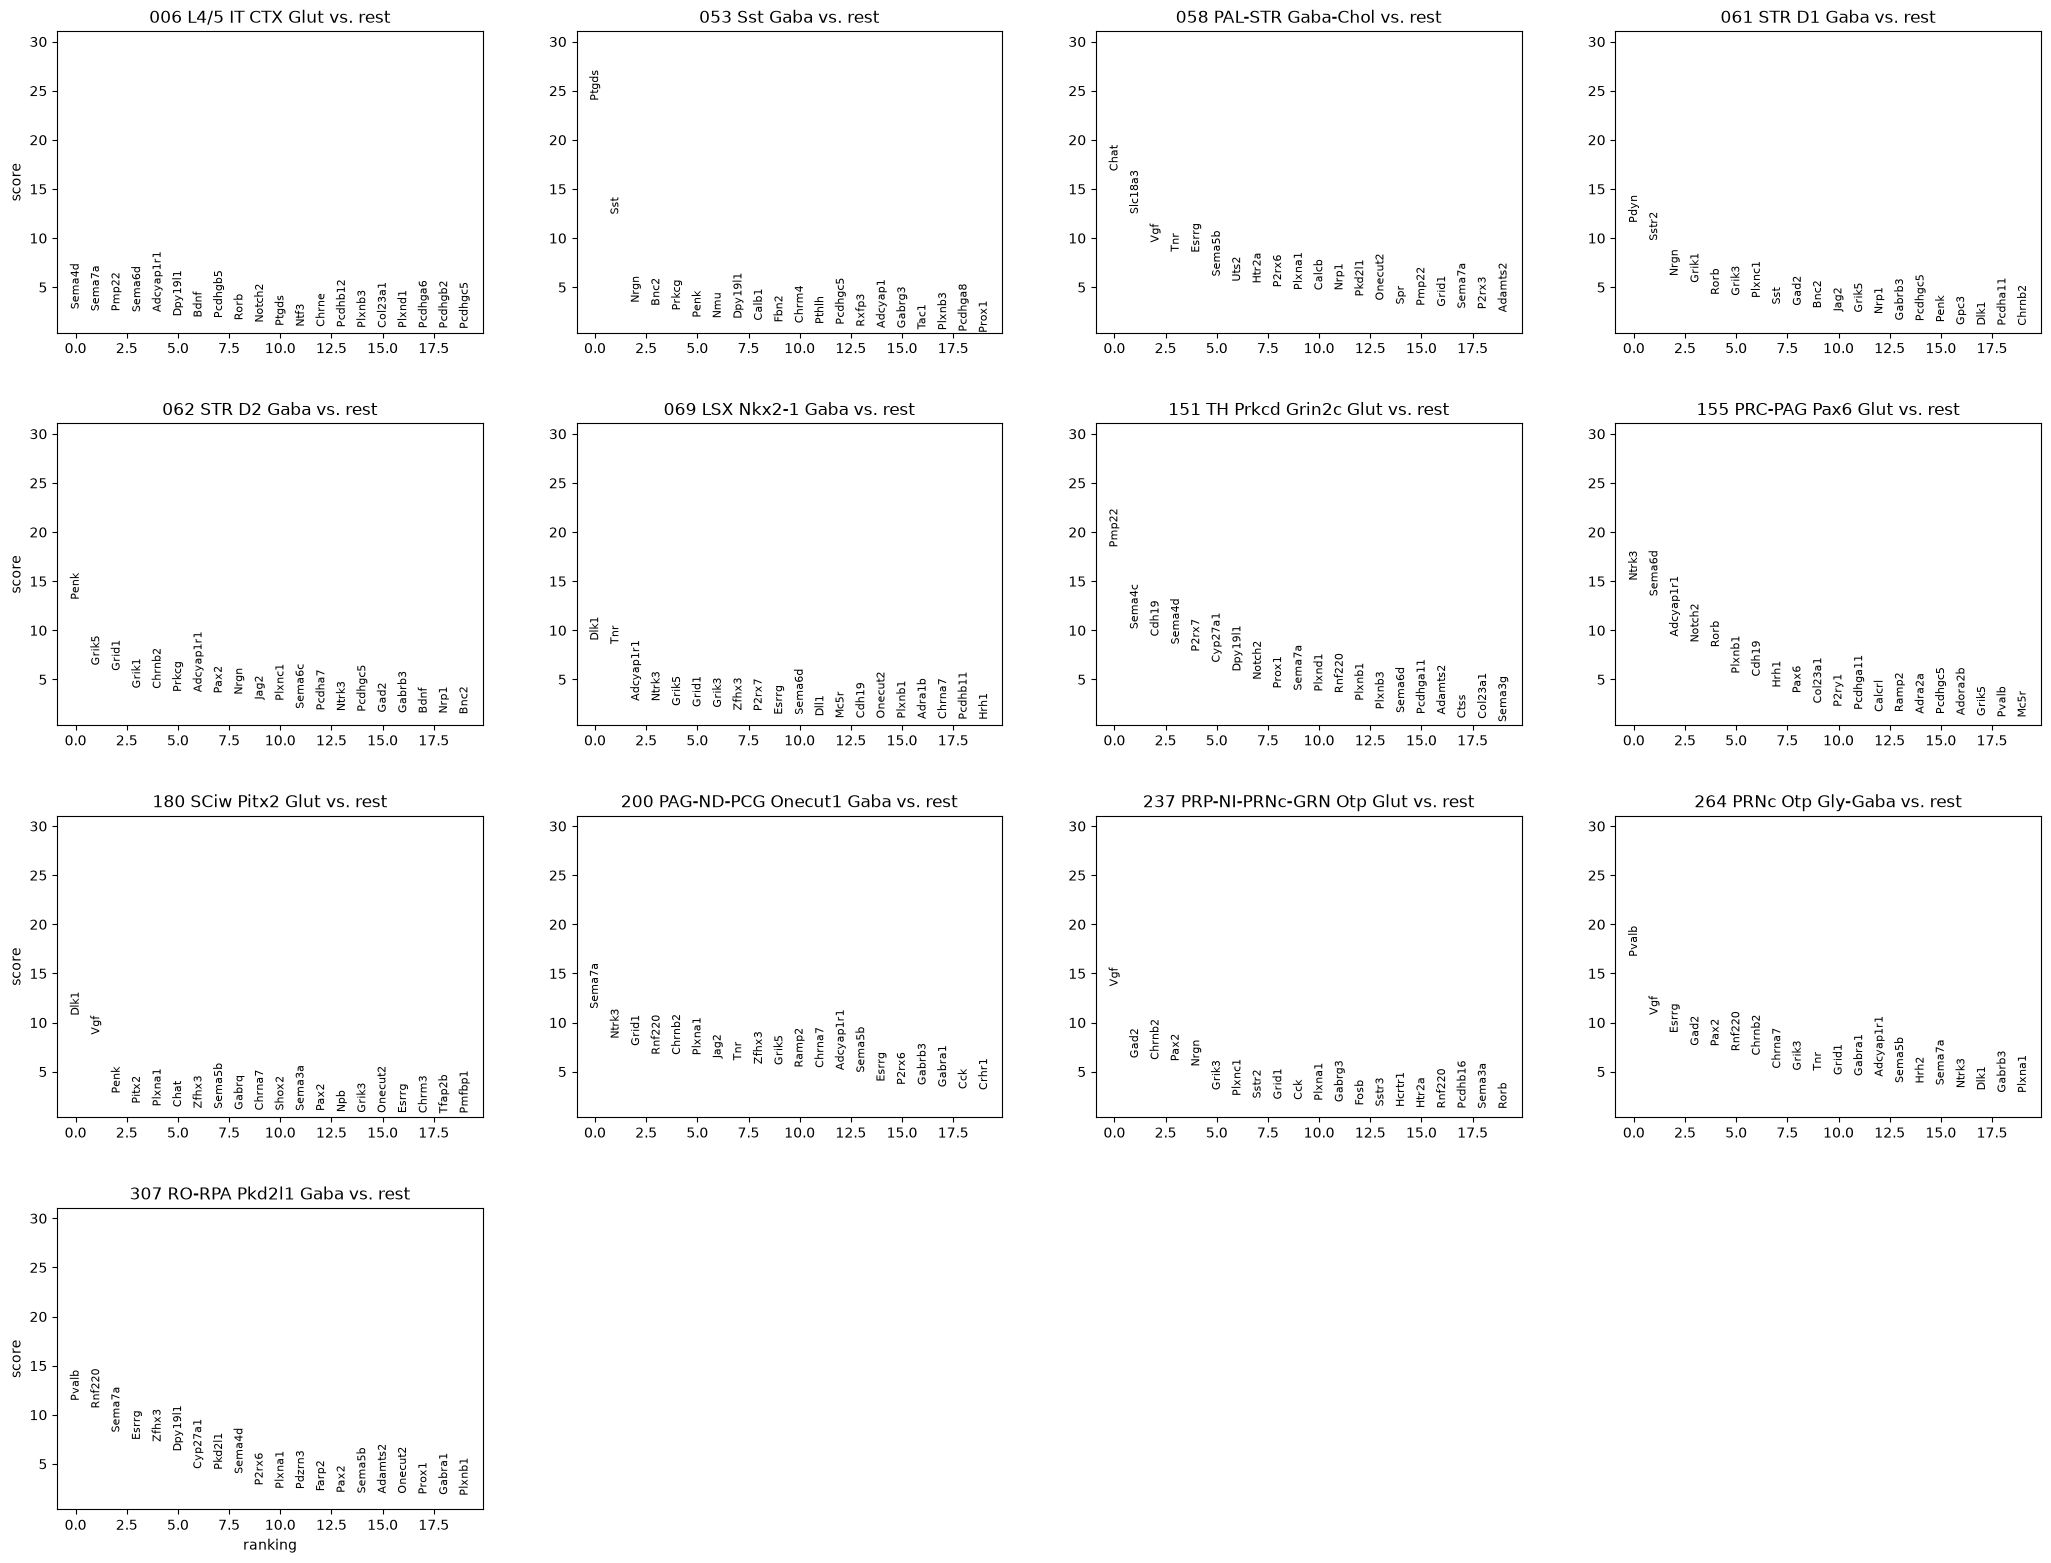

In [202]:
'CELLTYPIST Classifications Check -Paulete'

adata_train.obs['celltypist'] = pred.predicted_labels['majority_voting']
sc.pl.umap(adata_train, color='celltypist')
# cell typist spatial graph is specific and makes sense with leiden spatial graph

sc.tl.rank_genes_groups(adata_train, 'celltypist', method='wilcoxon')
sc.pl.rank_genes_groups(adata_train, n_genes=20)


# HOW TO UNDERSTAND CELL TYPIST LABELS !!!
# First 3 numbers are the model cluster ID (not super relevant for us)
# Portion usually following in all caps is brain region abbreviation (e.g. RO-RPA = Rostral Raphe Area, TH= Thalamus
# Next portion is marker gene (e.g. Sst) (sometimes there are multiple)
# Next portion is neurotransmitter functional class (e.g Glut = excitatory neuron, Gaba= inhibitory neuron)


#NOTE!!! Celltypist only focuses on refining neuron classification, not non-neural cells
# we could possible combine MERFISH Annotations with Celltypist classification

In [236]:
"List of CellTypist Neural Cell Types for Reference -Paulete"

model = celltypist.models.Model.load('Mouse_Whole_Brain.pkl')
print(model.cell_types)

['001 CLA-EPd-CTX Car3 Glut' '002 IT EP-CLA Glut'
 '003 L5/6 IT TPE-ENT Glut' '004 L6 IT CTX Glut' '005 L5 IT CTX Glut'
 '006 L4/5 IT CTX Glut' '007 L2/3 IT CTX Glut' '008 L2/3 IT ENT Glut'
 '009 L2/3 IT PIR-ENTl Glut' '010 IT AON-TT-DP Glut'
 '011 L2 IT ENT-po Glut' '012 MEA Slc17a7 Glut' '013 COAp Grxcr2 Glut'
 '014 LA-BLA-BMA-PA Glut' '015 ENTmv-PA-COAp Glut' '016 CA1-ProS Glut'
 '017 CA3 Glut' '018 L2 IT PPP-APr Glut' '019 L2/3 IT PPP Glut'
 '020 L2/3 IT RSP Glut' '021 L4 RSP-ACA Glut' '022 L5 ET CTX Glut'
 '023 SUB-ProS Glut' '024 L5 PPP Glut' '025 CA2-FC-IG Glut'
 '026 NLOT Rho Glut' '027 L6b EPd Glut' '028 L6b/CT ENT Glut'
 '029 L6b CTX Glut' '030 L6 CT CTX Glut' '031 CT SUB Glut'
 '032 L5 NP CTX Glut' '033 NP SUB Glut' '034 NP PPP Glut'
 '035 OB Eomes Ms4a15 Glut' '036 HPF CR Glut' '037 DG Glut'
 '038 DG-PIR Ex IMN' '039 OB Meis2 Thsd7b Gaba' '040 OB Trdn Gaba'
 '041 OB-in Frmd7 Gaba' '042 OB-out Frmd7 Gaba' '043 OB-mi Frmd7 Gaba'
 '044 OB Dopa-Gaba' '045 OB-STR-CTX Inh IMN' '0

In [270]:
"COMPARING CELL TYPIST AND MERFISH LABELS -Paulete"

## Could be used as a quality check ##
print(sorted(adata_train.obs["MERFISH_cell_type_annotation"].unique()))

# MERFISH Cell Type Labels are informative enough
# they are comprehensive of cell types in brain then the Celltypist stuff, that only refine neural cells

# Advantage of Cell Typist
# CellTypist gives atlas‑standard neuron classes
# so u can see MERFISH neuronal clusters and how they allign with well‑known types like Sst
# Basically celltypist can be a quality check for later to see if MERFISH neuronal cluster are like neuron types in Allen Brain Atlas

#HOWEVER, SCANVI seems to be a more comprehensive reference

['DH_ex_Cpne4', 'DH_ex_Gpr83', 'DH_ex_Grp', 'DH_ex_Grpr', 'DH_ex_Maf/Cck', 'DH_ex_Maf/Cpne4', 'DH_ex_Maf/Slc17a8', 'DH_ex_Nmu/Tac2', 'DH_ex_Prkcg/Cck', 'DH_ex_Prkcg/Nts', 'DH_ex_Prkcg/Rxfp1', 'DH_ex_Reln', 'DH_ex_Reln/Nmur2', 'DH_ex_Reln/Npff', 'DH_ex_Rreb1', 'DH_ex_Sox5', 'DH_ex_Sox5/Tac1', 'DH_ex_Tac2', 'DH_in_Cdh3', 'DH_in_Kcnip2', 'DH_in_Klhl14', 'DH_in_Npy', 'DH_in_Npy2r', 'DH_in_Pdyn', 'DH_in_Pdyn/Gal', 'DH_in_Rorb', 'DM_ex_Zfhx3', 'MV_ex_Shox2', 'MV_ex_Syt2', 'MV_in_Chrna2', 'MV_in_Esrrb', 'MV_in_Gabra1', 'MV_in_Gm26673', 'MV_in_Sema5b', 'M_ex_Neurod2', 'M_ex_Vsx2', 'M_ex_Vsx2/Shox2', 'M_in_Tfap2b', 'Schwann_cell', 'VH_in_Chat', 'alpha_motoneuron', 'astrocyte_1', 'astrocyte_2', 'beta_motoneuron', 'cholinergic_interneuron', 'endothelial', 'ependymal', 'gamma_motoneuron', 'meninges_1', 'meninges_2', 'meninges_3', 'microglia', 'oligodendrocyte_1', 'oligodendrocyte_2', 'oligodendrocyte_precursor_cell', 'oligodendrocyte_progenitor_1', 'oligodendrocyte_progenitor_2', 'pericyte', 'peri

"\n# Cell typist will provide more speicifc neural classifications,\n# while merfish will take over for non neural cells like Microglia\n\nnon_neuronal = [\n \n]\n\ndef merge_labels(row):\n    if row['MERFISH_cell_type_annotation'] in non_neuronal:\n        return row['MERFISH_cell_type_annotation']\n    else:\n        return row['celltypist']\n\nadata_train.obs['final_annotation'] = adata_train.obs.apply(merge_labels, axis=1)\n"

/root/venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)
/root/venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


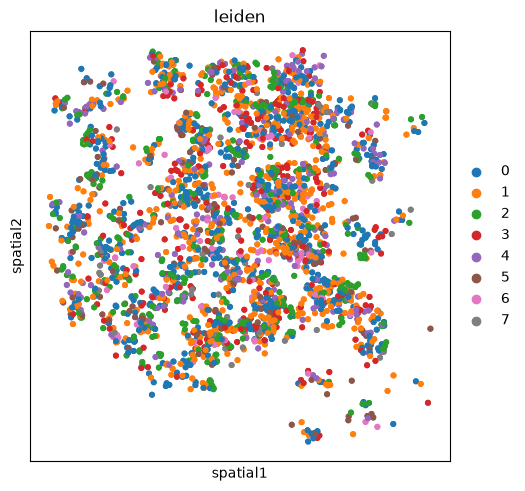

In [49]:
sq.pl.spatial_scatter(adata_train,shape=None, color = ["leiden"],wspace = 0.4)

In [83]:
'''Cell2location for deconvolution '''
#cell2location 
import cell2location 
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel



In [280]:
#load data 


train =sq.read.vizgen(path = "." ,counts_file = 'counts_train.csv', meta_file = 'meta_train.csv') # reads files from 
test = sq.read.vizgen(path = "." ,counts_file = 'counts_test.csv', meta_file = 'meta_test.csv') # reads files from 

#normalize 
sc.pp.normalize_total(train,inplace = True) # normalize counts per cell 
sc.pp.log1p(train) # log

sc.pp.normalize_total(test,inplace = True) # normalize counts per cell 
sc.pp.log1p(test) # log

# need all the cells in common: 


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 74294 stored elements and shape (5000, 200)>
  Coords	Values
  (0, 12)	0.5447272062301636
  (0, 26)	0.5447272062301636
  (0, 38)	0.5447272062301636
  (0, 86)	0.5447272062301636
  (0, 102)	0.5447272062301636
  (0, 107)	1.360092043876648
  (0, 120)	0.5447272062301636
  (0, 139)	0.8953840732574463
  (0, 156)	0.5447272062301636
  (0, 157)	0.8953840732574463
  (0, 182)	0.5447272062301636
  (0, 189)	0.5447272062301636
  (0, 197)	2.2710587978363037
  (1, 1)	1.067840576171875
  (1, 34)	1.067840576171875
  (1, 57)	1.9061697721481323
  (1, 82)	1.067840576171875
  (1, 91)	1.067840576171875
  (1, 107)	1.5723965167999268
  (1, 164)	1.067840576171875
  (1, 197)	1.067840576171875
  (2, 1)	0.9162907600402832
  (2, 6)	0.9162907600402832
  (2, 8)	0.9162907600402832
  (2, 11)	0.9162907600402832
  :	:
  (4998, 145)	0.6486954092979431
  (4998, 150)	1.0388931035995483
  (4998, 164)	0.6486954092979431
  (4998, 175)	0.6486954092979431
  (4998, 177)

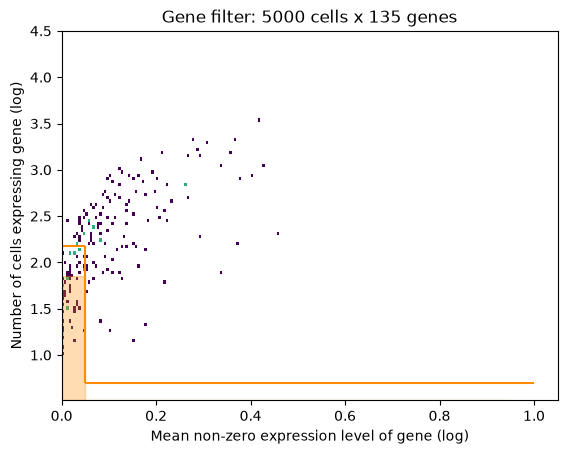

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Epoch 250/250: 100%|██████████| 250/250 [00:46<00:00,  5.33it/s, v_num=1, elbo_train=3.14e+5]


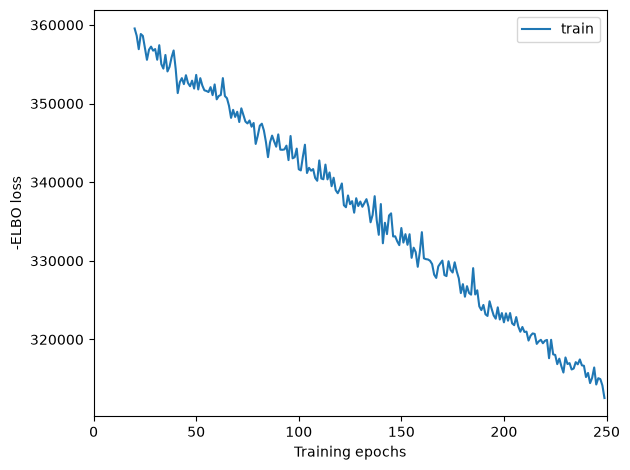

In [158]:
adata_train_cell2 =sq.read.vizgen(path = "." ,counts_file = 'counts_train.csv', meta_file = 'meta_train.csv') # reads files from 




selected = filter_genes(adata_train_cell2,cell_count_cutoff = 5 ,cell_percentage_cutoff2 = 0.03) # filter the genes

#RegressionModel actually learns the relationship between gene expression and your cell-type labels.
RegressionModel.setup_anndata(adata =adata_train_cell2 )

mod = RegressionModel(adata_train_cell2)
#mod.view_anndata_setup()

mod.train(max_epochs=250) # want the general trend to be a downward trend which it is showing our trainig model is good
mod.plot_history(20)

In [172]:
newdata = mod.export_posterior(adata_train_cell2) # exporting the learned behavior 


Sampling global variables, sample: 100%|██████████| 999/999 [00:02<00:00, 391.17it/s]


In [196]:
# testing data: 
adata_test = sq.read.vizgen(path = "." ,counts_file = 'counts_test.csv', meta_file = 'meta_test.csv') # reads files from 
adata_test.var

""
Pmfbp1
Sema7a
Bdnf
Cck
Sema3a
...
Chrng
Chrnb3
Pkd2l1
Hrh1


### Sofia's prediction process: 

In [121]:
# scVI label transfer 

# reference data 
counts_train_1 = pd.read_csv("counts_train.csv",index_col=0)
meta_train_1= pd.read_csv("meta_train.csv",index_col = 0)

adata_training = ad.AnnData(X=counts_train_1,obs=meta_train_1.loc[counts_train_1.index])

#test data 
counts_test_1 = pd.read_csv("counts_test.csv",index_col=0)
meta_test_1= pd.read_csv("meta_test.csv",index_col = 0)

adata_test = ad.AnnData(X=counts_test_1,obs=meta_test_1.loc[counts_test_1.index])

# concatenate the reference and test data 
concat_adata = ad.concat([adata_test,adata_training])


/usr/local/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [123]:
import scvi
import scvi.model

print(scvi.__version__)


1.5.0.post1


In [125]:
# preprocessing data 
concat_adata.layers["counts"] = concat_adata.X.copy() # save a counts layer 
sc.pp.normalize_total(concat_adata,target_sum=1e4) # 
sc.pp.log1p(concat_adata)



In [ ]:
# model 
scvi.model.SCVI.setup_anndata(concat_adata,layer = 'counts') #making model 
tmodel = scvi.model.SCVI(concat_adata) #training model
tmodel.train(max_epochs=250)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
Epoch 197/250:  78%|███████▊  | 196/250 [09:19<02:36,  2.89s/it, v_num=1, train_loss=47.1]

<Axes: xlabel='epoch'>

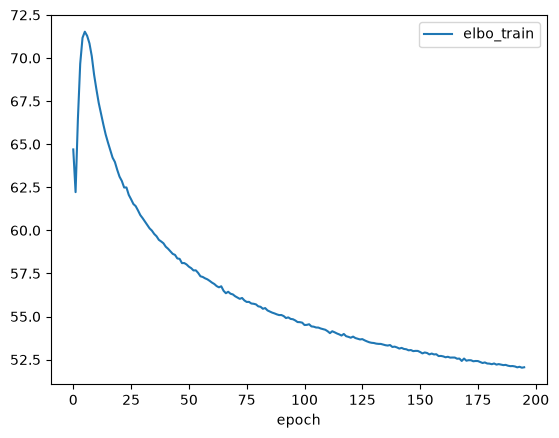

In [133]:
tmodel.history['elbo_train'].plot() # mapping the history of the epoch training model

#can probably decrease epoch to like 200

In [141]:
# convert NaN of testing data to a string 
concat_adata.obs['MERFISH_cell_type_annotation'] = concat_adata.obs['MERFISH_cell_type_annotation'].fillna("Unknown")

In [145]:
# using the scvi model to predict the unknown cells 
learnedmodel = scvi.model.SCANVI.from_scvi_model(tmodel,adata=concat_adata,unlabeled_category='Unknown',labels_key = 'MERFISH_cell_type_annotation')
learnedmodel.train(max_epochs=20,n_samples_per_label = 100)


INFO     Training for 20 epochs.                                                                                   
/root/venv/lib/python3.12/site-packages/scvi/model/_scanvi.py:240: UserWarning: Passed in scvi model hasn't been trained yet.
  scvi_model._check_if_trained(message="Passed in scvi model hasn't been trained yet.")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 

In [155]:
# Predicted probabilties of the labels for each cell 
softpredictions = learnedmodel.predict(concat_adata,soft= True)
concat_adata.obs["scanvi_confidence"] = softpredictions.max(axis=1).values
concat_adata.obs

,Datasets,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory,Segment,Gender,Mouse_ID,AP_position,Section_ID,_scvi_batch,_scvi_labels,scanvi_confidence
2796212800954100068,20240613,3647.375000,9979.925856,8091.551222,Unknown,1.0,excitatory,2.0,female,F4,1,0613_F4_C,0,60,0.523415
2707604000123100074,20240415,1100.773071,5385.479527,9654.331573,Unknown,NaN,NaN,NaN,male,M3,4,0415_M3_T,0,60,0.641934
2796212800080100088,20240613,3029.895508,7193.083494,550.081350,Unknown,NaN,NaN,NaN,female,F5,3,0613_F5_S,0,60,0.589697
2946331700000000970,20240415,3262.542236,8948.681067,309.374372,Unknown,NaN,NaN,NaN,female,F2,1,0415_F2_C,0,60,0.997387
2796212800882100299,20240613,1551.463623,7788.225136,7682.970213,Unknown,1.0,inhibitory,7.0,female,F3,1,0613_F3_C,0,60,0.429607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2787889600584100018,20240503,2181.030273,4493.072590,10236.945614,pericyte,NaN,NaN,NaN,male,M4,3,0503_M4_S,0,58,0.985885
2795584800435100084,20240610,3171.459473,866.268481,7194.637866,DH_ex_Sox5/Tac1,1.0,excitatory,5.0,female,F4,1,0610_F4_C,0,16,0.961987
2787445900655100067,20240503,3561.134766,7459.250365,4780.936155,astrocyte_1,NaN,NaN,NaN,female,F3,1,0503_F3_C,0,42,0.997356
2787445900618100152,20240503,4568.070312,7363.552587,4649.108635,oligodendrocyte_2,NaN,NaN,NaN,female,F3,1,0503_F3_C,0,54,0.973152


In [191]:
# Predicted hard labels 
concat_adata.obs['predicted'] = learnedmodel.predict(concat_adata) # adds column of all the predicted cell types
concat_adata = concat_adata[:len(concat_adata)//2]
concat_adata.obs

,Datasets,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory,Segment,Gender,Mouse_ID,AP_position,Section_ID,_scvi_batch,_scvi_labels,scanvi_confidence,predicted
2796212800954100068,20240613,3647.375000,9979.925856,8091.551222,Unknown,1.0,excitatory,2.0,female,F4,1,0613_F4_C,0,60,0.523415,DH_ex_Grpr
2707604000123100074,20240415,1100.773071,5385.479527,9654.331573,Unknown,NaN,NaN,NaN,male,M3,4,0415_M3_T,0,60,0.641934,oligodendrocyte_1
2796212800080100088,20240613,3029.895508,7193.083494,550.081350,Unknown,NaN,NaN,NaN,female,F5,3,0613_F5_S,0,60,0.589697,astrocyte_1
2946331700000000970,20240415,3262.542236,8948.681067,309.374372,Unknown,NaN,NaN,NaN,female,F2,1,0415_F2_C,0,60,0.997387,oligodendrocyte_2
2796212800882100299,20240613,1551.463623,7788.225136,7682.970213,Unknown,1.0,inhibitory,7.0,female,F3,1,0613_F3_C,0,60,0.429607,DH_in_Cdh3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2787889600409100230,20240503,1029.303711,6057.870768,9031.221613,Unknown,NaN,NaN,NaN,male,M4,2,0503_M4_L,0,60,0.669187,DH_ex_Maf/Cck
2795584800388100027,20240610,2450.753418,8097.346720,6582.207908,Unknown,NaN,NaN,NaN,female,F4,3,0610_F4_S,0,60,0.680509,M_in_Tfap2b
2656143800130100146,20240328,2418.427979,2592.243209,3928.415030,Unknown,NaN,NaN,NaN,male,M3,1,0328_M3_C,0,60,0.716945,astrocyte_1
2707604700272100140,20240415,2361.355957,4211.393281,8374.764167,Unknown,NaN,NaN,NaN,male,M2,4,0415_M2_T,0,60,0.290910,oligodendrocyte_progenitor_2


### histogram of confidence scores 

(array([ 29.,  96., 198., 295., 331., 393., 419., 394., 337., 353., 310.,
        359., 338., 370., 778.]),
 array([0.11657181, 0.17546692, 0.23436207, 0.29325718, 0.35215232,
        0.41104743, 0.46994257, 0.52883768, 0.58773279, 0.6466279 ,
        0.70552301, 0.76441818, 0.8233133 , 0.88220841, 0.94110358,
        0.99999869]),
 <BarContainer object of 15 artists>)

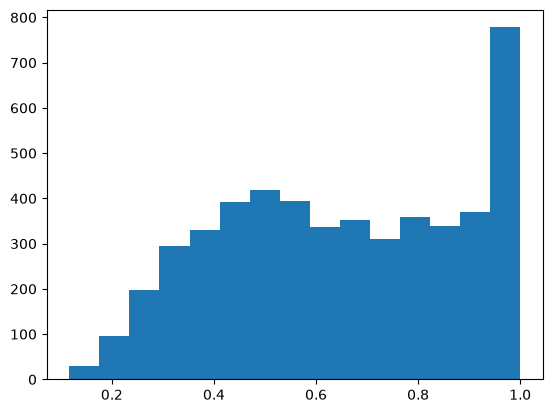

In [203]:
plt.hist(concat_adata.obs["scanvi_confidence"],bins=15)

In [205]:
# uploading cell id and merfish annotation predicted 
upload = concat_adata.obs['predicted'].reset_index()
upload = upload.rename(columns = {'index':'Cell_ID','predicted':'MERFISH_cell_type_annotation.y'})
upload

,Cell_ID,MERFISH_cell_type_annotation.y
0,2796212800954100068,DH_ex_Grpr
1,2707604000123100074,oligodendrocyte_1
2,2796212800080100088,astrocyte_1
3,2946331700000000970,oligodendrocyte_2
4,2796212800882100299,DH_in_Cdh3
...,...,...
4995,2787889600409100230,DH_ex_Maf/Cck
4996,2795584800388100027,M_in_Tfap2b
4997,2656143800130100146,astrocyte_1
4998,2707604700272100140,oligodendrocyte_progenitor_2


In [117]:
upload.to_csv('sofia_prediction.csv', index=False)

NameError: name 'upload' is not defined

Mean confidence per cell: 0.6497211
Min confidence per cell: 0.11657181
Max confidence per cell: <bound method Series.max of 2796212800954100068    0.523415
2707604000123100074    0.641934
2796212800080100088    0.589697
2946331700000000970    0.997387
2796212800882100299    0.429607
                         ...   
2787889600409100230    0.669187
2795584800388100027    0.680509
2656143800130100146    0.716945
2707604700272100140    0.290910
2787445900694100124    0.366582
Name: scanvi_confidence, Length: 5000, dtype: float32>


'\nimport scanpy as sc\n\nsc.pl.umap( # UMAP of single cell confidence, HIGH CONFIDENCE= yellow, LOW CONFIDENCE= blue, aka how sure are u of final prediciton\n    concat_adata,\n    color="SCANVI_confidence",\n    cmap="viridis",   \n    vmin=0,\n    vmax=1,\n    title="SCANVI Confidence per Cell"\n)\n\n#visualizing confidence score for full prov distribution\n\nimport scanpy as sc\n\nfull_dist_stats = {}\n\nfor ct in cell_types:\n    col = f"prob_{ct}"\n    full_dist_stats[ct] = {\n        "mean": concat_adata.obs[col].mean(),\n        "min": concat_adata.obs[col].min(),\n        "max": concat_adata.obs[col].max()\n    }\n\nprint(full_dist_stats) # gives a dict of mean probability scores per cell type\n\nfor ct in learnedmodel.labels:\n    sc.pl.umap(\n        concat_adata,\n        color=f"prob_{ct}",\n        cmap="magma", # brighter = looks more like the avg cell of that type, darker= less\n        vmin=0,\n        vmax=1,\n        title=f"Probability of {ct}"\n    )\n'

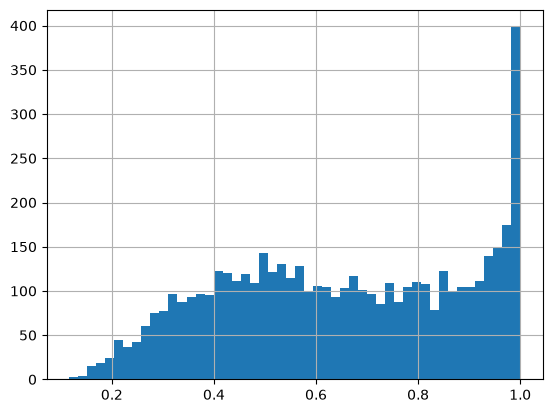

In [219]:
'SCANVI MODEL PREDICTIONS CONFIDENCE SCORES -Paulete'

import numpy as np

dir(learnedmodel)

'''
# store maximum confidence per cell
#probs = learnedmodel.predict_proba(concat_adata)
#concat_adata.obs["SCANVI_confidence"] = probs.max(axis=1) #SCANVI_confidence= single confidence per cell

'''
# store full probability distribution
cell_types = learnedmodel.labels
for i, ct in enumerate(cell_types):
    concat_adata.obs[f"prob_{ct}"] = probs[:, i] #prob_celltype=full probability distribution

'''

# visualizing confidence scores for max confidence per cell
mean_conf = concat_adata.obs["scanvi_confidence"].mean()
min_conf = concat_adata.obs["scanvi_confidence"].min()
max_conf = concat_adata.obs["scanvi_confidence"].max

print("Mean confidence per cell:", mean_conf)
print("Min confidence per cell:", min_conf)
print("Max confidence per cell:", max_conf)


concat_adata.obs["scanvi_confidence"].hist(bins=50) # single cell confidence historgam
'''
import scanpy as sc

sc.pl.umap( # UMAP of single cell confidence, HIGH CONFIDENCE= yellow, LOW CONFIDENCE= blue, aka how sure are u of final prediciton
    concat_adata,
    color="SCANVI_confidence",
    cmap="viridis",   
    vmin=0,
    vmax=1,
    title="SCANVI Confidence per Cell"
)

#visualizing confidence score for full prov distribution

import scanpy as sc

full_dist_stats = {}

for ct in cell_types:
    col = f"prob_{ct}"
    full_dist_stats[ct] = {
        "mean": concat_adata.obs[col].mean(),
        "min": concat_adata.obs[col].min(),
        "max": concat_adata.obs[col].max()
    }

print(full_dist_stats) # gives a dict of mean probability scores per cell type

for ct in learnedmodel.labels:
    sc.pl.umap(
        concat_adata,
        color=f"prob_{ct}",
        cmap="magma", # brighter = looks more like the avg cell of that type, darker= less
        vmin=0,
        vmax=1,
        title=f"Probability of {ct}"
    )
'''
'''

## Seren Workspace:

In [125]:
### OLD CODE ###
'''
# Make sure I have the correct names for the training data

print("Cell type counts: ")
print(counts_train.obs["MERFISH_cell_type_annotation"].value_counts().head())

# Will also create copies for all of the data
counts_train.layers["counts"] = counts_train.X.copy()

#counts_test.layers["counts"] = counts_test.X.copy()

'''

Cell type counts: 
MERFISH_cell_type_annotation
oligodendrocyte_progenitor_2    386
astrocyte_1                     304
oligodendrocyte_2               237
endothelial                     167
oligodendrocyte_1               139
Name: count, dtype: int64


In [146]:
### OLD CODE ###
'''

# This cell focuses on using the AnnData package to see the 
# gene expression information

#counts_test_grid = counts_test.astype(np.int32)
#print(counts_test_grid)

# This will create the AnnData object that we will use in further analyses
adata = adata_train.copy()

sc.pp.calculate_qc_metrics(
    adata,
    percent_top=None,
    inplace=True,
    log1p=True 
)

print(adata.obs[["total_counts", "n_genes_by_counts"]].describe())

'''

'''
# Don't know if I necessarily need this. It is a good visualizer tho
sc.pl.violin(
    adata, 
    ["n_genes_by_counts", "total_counts"],
    jitter = 0.4,
    multi_panel=True
    )

sc.pl.scatter(
    adata,
    y = "n_genes_by_counts",
    x = "total_counts"
)
'''

# Filtering

# Don't know if this is the correct filter so I will leave alone for now
#sc.pp.filter_cells(adata, min_counts=20)
#sc.pp.filter_genes(adata, min_cells=3)



# OLD Code
'''
adata.obs_names = counts_test.columns
adata.var_names = counts_test.index

adata.layers["counts"] = adata.X.copy()
# adata.layers["counts"] contains the raw counts, but we want to make a copy
# so we do not overwrite the original file

print(adata)
print(adata.obs_names[:5])
print(adata.var_names[:5])
#print(adata.obs["n_genes_by_counts"].describe())

#adata.obs = meta_test

'''

       total_counts  n_genes_by_counts
count   2733.000000        2733.000000
mean      16.448145          19.814490
std        3.647334           9.882119
min        3.555348           1.000000
25%       14.742347          14.000000
50%       17.056057          18.000000
75%       18.878304          24.000000
max       24.805515          85.000000


'\nadata.obs_names = counts_test.columns\nadata.var_names = counts_test.index\n\nadata.layers["counts"] = adata.X.copy()\n# adata.layers["counts"] contains the raw counts, but we want to make a copy\n# so we do not overwrite the original file\n\nprint(adata)\nprint(adata.obs_names[:5])\nprint(adata.var_names[:5])\n#print(adata.obs["n_genes_by_counts"].describe())\n\n#adata.obs = meta_test\n\n'

In [210]:
### OLD CODE ###
'''
# I just keeping making copies so the analyses I have does not give overwritten
# in case something happens downstream

adata2 = adata.copy()

## Normalization
sc.pp.normalize_total(adata2, inplace=True)
sc.pp.log1p(adata2)

# PCA
sc.pp.pca(adata2)

# Neighbor Graph that will find cells with similar gene expressions
sc.pp.neighbors(adata2)

# UMAP which is for the visualiation of the neighbor graph
# It is similar to a PCA plot, but varies in its process
sc.tl.umap(adata2)


# Need to do Leiden Clustering
# It "groups interconnected nodes—such as cells in single-cell RNA sequencing 
# or users in social networks—by optimizing modularity."
## This will further group cells with similar gene expression profiles

'''

'''
sc.tl.leiden(adata2, resolution=0.5)

# The actual visualization of the cluster. 
sc.pl.umap(
    adata2,
    color="leiden",
    legend_loc="on data",
    size=5,
    wspace=0.4
)

# Interestingly, not the same as above
'''

'\nsc.tl.leiden(adata2, resolution=0.5)\n\n# The actual visualization of the cluster. \nsc.pl.umap(\n    adata2,\n    color="leiden",\n    legend_loc="on data",\n    size=5,\n    wspace=0.4\n)\n\n# Interestingly, not the same as above\n'

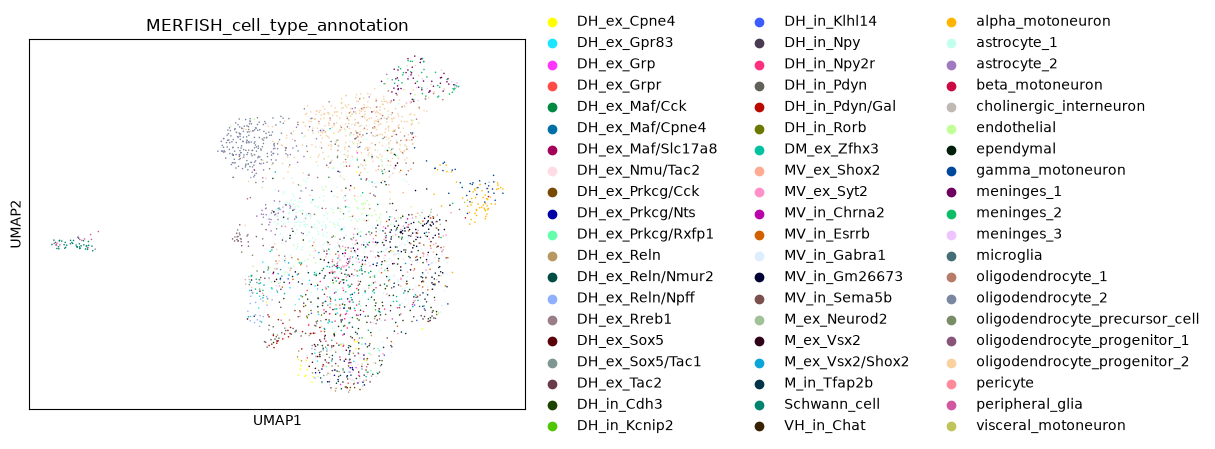

In [41]:
# This gives the plot to see all of the different cell types that is in our
# data and will be used

sc.pl.umap(
    adata_train, #adata2
    color="MERFISH_cell_type_annotation",
    legend_loc="right margin",
    size=5
)

clusters = pd.crosstab(
    adata_train.obs["leiden"],#adata2
    adata_train.obs["MERFISH_cell_type_annotation"]
)
#print(clusters)

In [43]:
# Making a copy again
adata_model = adata_train.copy()

adata_model.layers["counts"] = adata_model.X.copy()

# Will need to now filter the genes instead of just the cells
sc.pp.filter_genes(adata_model, min_cells=5)

print("We have this many genes after filerting: ", adata_model.n_vars)

# this is just to make sure all of the cell types are categories and don't run into any issues downstream
adata_model.obs["MERFISH_cell_type_annotation"] = adata_model.obs["MERFISH_cell_type_annotation"].astype("category")

We have this many genes after filerting:  199


In [51]:
# Need to train the model. Can use SCANVI since it is used for single-cell and spatial
# transcriptomics. 
# From google: "It extends scVI by using known cell-type labels for a subset of cells to train 
# a classifier and accurately predict or transfer labels to the remaining unlabeled cells"

SCANVI.setup_anndata(
    adata_model,
    layer="counts",
    labels_key="MERFISH_cell_type_annotation",
    unlabeled_category="Unknown"

)

# Need to actually create the model
spatial_model_1 = SCANVI(adata_model) ## Don't add unlabeled_category since it won't work

# Now need to train the actual model
# Was going to do 100 epochs, but would be too intensive so ran for 30 epochs instead
spatial_model_1.train(max_epochs=100)

INFO     Training for 100 epochs.                                                                                  
/root/venv/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be

In [75]:
"SCANVI/SCVI MODEL -Paulete"
# SCVI = unsupervided model, doesnt actually use the labels 
# SCANVI = semi supervised model, using our MERFISH labels

from scvi.model import SCVI, SCANVI
import scvi

# MANUAL RESET OF ANN DATA (so other blocks dont affect labels)
for key in ["_scvi", "_scvi_uuid", "_scvi_data_registry"]:
    adata_model.uns.pop(key, None)

for key in list(adata_model.obsm.keys()):
    if key.startswith("_scvi"):
        del adata_model.obsm[key]

for key in list(adata_model.obsp.keys()):
    if key.startswith("_scvi"):
        del adata_model.obsp[key]

for key in list(adata_model.var.keys()):
    if key.startswith("_scvi"):
        del adata_model.var[key]

for key in list(adata_model.obs.keys()):
    if key.startswith("_scvi"):
        del adata_model.obs[key]


# set up annotation data for scvi

SCVI.setup_anndata(
    adata_model,
    layer="counts", 
    labels_key="MERFISH_cell_type_annotation"
)


# training unsupervised SCVI model

scvi_model = SCVI(adata_model)
scvi_model.train() 

# setting up scanvi annotation data  wt/ merfish labels 
SCANVI.setup_anndata( 
    adata_model,
    layer="counts",
    labels_key="MERFISH_cell_type_annotation",
    unlabeled_category="Unknown"
)

# Making a SCANVI model using SCANVI from SCVI (two step training)

spatial_model = SCANVI.from_scvi_model( # build SCANVI from SCVI
    scvi_model,
    unlabeled_category="Unknown"
)
spatial_model.train()

# NEXT, GET SCANVI LABEL PREDICTIONS
adata_model.obs["SCANVI_label"] = spatial_model.predict()



/root/venv/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` 

In [309]:
" VISUALIZE THE CONFIDENCE SCORES FROM SCVI/SCANVI MODEL -Paulete"

adata_model.obs["SCANVI_confidence"] = spatial_model.predict_proba().max(1) # this needs to be debugged
adata_model.obs["SCANVI_confidence"].hist(bins=50)


# FOLLOWING STEPS:
# after this, we want ot identify low confidence cells
# we can visualize low confidence cell zones on a UMAP as well
# then, we compare our scanvi labels to the MERFISH labels to see error ( to see if misanotation, unlabeled cells, overly broad labels?)
# identify the bad labels, rebuild labels, and revisualzie with corrected labels

KeyError: 'SCANVI_confidence'

In [53]:
print(spatial_model_1)

# Minified is false which means that is contains the full dataset and is not reduced/compressed
# So that should not be an issue

ScanVI Model with the following params: 
unlabeled_category: Unknown, n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb
Training status: Trained
Model's adata is minified?: False

In [55]:
# Now we need to load the test data so the model can be further trained on it

# From squidpy the read.vizgen reads the metadata file along with reading the regular Vizgen output
# More info: https://squidpy.readthedocs.io/en/latest/api/squidpy.read.vizgen.html
adata_test2 = sq.read.vizgen(
    path=".",
    counts_file="counts_test.csv",
    meta_file="meta_test.csv" # can't use the variable meta_test. It has to be the actual file name FYI
)

print(adata_test2) # Seems to work?

adata_test2.layers["counts"] = adata_test2.X.copy()
print(adata_test2.layers.keys())
#print(adata_test2.obs.columns) # Has the correct file names. I think I am good

AnnData object with n_obs × n_vars = 5000 × 200
    obs: 'Datasets', 'volume', 'MERFISH_cell_type_annotation', 'Region', 'Excitatory_vs_Inhibitory', 'Segment', 'Gender', 'Mouse_ID', 'AP_position', 'Section_ID'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'
    layers: None (.X)
KeysView(Layers with keys: None, 'counts')


In [57]:
# Need to the genes that we used for the training to be used within the model and the dataset
model_genes = adata_model.var_names.intersection(adata_test2.var_names)

print(model_genes)

#print(adata_test2.obs)
print(type(spatial_model_1))

Index(['Pmfbp1', 'Sema7a', 'Bdnf', 'Cck', 'Sema3a', 'Sema3g', 'Adcyap1r1',
       'Drd5', 'Gabrb3', 'Slc6a3',
       ...
       'Zfhx3', 'Chat', 'Oprm1', 'Chrm3', 'Chrm4', 'Chrng', 'Chrnb3', 'Pkd2l1',
       'Hrh1', 'Chrna7'],
      dtype='str', length=199)
<class 'scvi.model._scanvi.SCANVI'>


In [61]:
# This seems to work. Still don't know if it is the model or the adata_test2
# Seems like it did something
test_prediction = spatial_model_1.predict(adata_model)
print(test_prediction[:20])

['oligodendrocyte_progenitor_2' 'pericyte' 'DH_in_Cdh3' 'MV_in_Gabra1'
 'oligodendrocyte_progenitor_2' 'DH_ex_Reln/Npff' 'astrocyte_1'
 'DH_ex_Prkcg/Rxfp1' 'oligodendrocyte_2' 'astrocyte_1' 'astrocyte_1'
 'DH_in_Cdh3' 'astrocyte_1' 'meninges_1' 'MV_in_Gm26673' 'M_in_Tfap2b'
 'astrocyte_1' 'astrocyte_1' 'DH_ex_Sox5' 'DH_ex_Sox5/Tac1']


In [63]:
## In order for this section to work, we need to drop the NA from the MERFISH labels

# print(adata_test2.obs.columns) # Need to see if the columns are okay
#print(adata_test2.obs.isna().sum()) # How many NAs are in each column
#print(adata_model.obs["MERFISH_cell_type_annotation"].value_counts(dropna=False))


## TBD if needed ##

'''
# Need to make sure about the NAs in the MERFISH column
if "MERFISH_cell_type_annotation" in adata_test2.obs.columns:
    #print(adata_test2.obs["MERFISH_cell_type_annotation"].value_counts(dropna=False))
    adata_test2.obs.drop(
    columns=["MERFISH_cell_type_annotation"],
    inplace=True)

'''
# Tells us which columns have missing NaN values and how many in each column
for column in adata_test2.obs.columns:
    missing = adata_test2.obs[column].isna().sum()

    if missing > 0:
        print(column, ":", missing)

#print(type(adata_test2))
#print(adata_test2)


MERFISH_cell_type_annotation : 5000
Region : 3177
Excitatory_vs_Inhibitory : 3177
Segment : 3004


In [67]:
# Need to add predictions to test the metadata

# Now need to actually prepare the test data for the trained model and data
adata_test3 = SCANVI.prepare_query_anndata(adata_test2, spatial_model_1, inplace=False)

print(type(adata_test3))
print(adata_test3)


# We need to predict the cell types
predict_cells = spatial_model_1.predict(adata_test3)

# 100% sounds good for the predictions

#adata_test2.obs["predicted_cell_type"] = predict_cells

# print(adata_test2.obs[["predicted_cell_type"]].head(10))

INFO     Found 100.0% reference vars in query data.                                                                
<class 'anndata.AnnData'>
AnnData object with n_obs × n_vars = 5000 × 199
    obs: 'Datasets', 'volume', 'MERFISH_cell_type_annotation', 'Region', 'Excitatory_vs_Inhibitory', 'Segment', 'Gender', 'Mouse_ID', 'AP_position', 'Section_ID'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'
    layers: None (.X), 'counts'
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


ValueError: Category nan not found in source registry. Cannot transfer setup without `extend_categories = True`.

## Tasmia's Workspace:

Load data
   ↓
Check data
   ↓
Explore gene expression
   ↓
Build spatial relationships
   ↓
Create ML features
   ↓
Validation
   ↓
Train final model
   ↓
Predict test cells
   ↓
prediction\.csv

### Load lib and data

In [71]:
%pip install -q "scanpy>=1.12,<1.13" "squidpy>=1.8,<1.9" \
    "scikit-learn>=1.5" "scipy>=1.11" "matplotlib>=3.8"


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [135]:
import csv # for csv file formattting
import gc # garbage collector: because gene expression consumes a lot of memory, deleted large matrices after use

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc # for PCA and Moran's I
import squidpy as sq # for spatial omics
from squidpy.gr.neighbors import KNNBuilder #lower-level K-nearest-neighbor graph builder (used n_neighs = 6)

from scipy import sparse
from scipy.sparse import coo_matrix # coordinate-format sparse-matrix constructor used to assemble a global graph from row, column, and value arrays.
from scipy.special import softmax # converts each row of classifier scores into positive values summing to one.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler # ohe converts categorical info into nums

"""
Linear Support Vector Machine Classifier: used because 
    1. Many feature 
    2. Sparse inputs 
    3. cell classes can often separated using combinations of marker genes
"""
from sklearn.svm import LinearSVC  

"""
Collection of randomized decision trees: used because 
   can learn non-linear relationships

combined both models as they learn different patterns
"""

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import f_classif

RANDOM_STATE = 42
TARGET = "MERFISH_cell_type_annotation"
ID_COL = "Unnamed: 0" # stores the CSV column that contains the cell identifier.

print("Scanpy:", sc.__version__)
print("Squidpy:", sq.__version__)

Scanpy: 1.12.3
Squidpy: 1.8.3
/tmp/ipykernel_125/335640642.py:42: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


In [137]:
counts_train = pd.read_csv('counts_train.csv')
counts_test  = pd.read_csv('counts_test.csv')
meta_train   = pd.read_csv('meta_train.csv')
meta_test    = pd.read_csv('meta_test.csv')

In [139]:
# verify: The count and metadata rows must refer to the same cell IDs. We also verify that training contains exactly 60 cell types

# provided data file has cell id as integer. To prevent pandas to read it as int, we type cast it into string
for df in (counts_train, counts_test, meta_train, meta_test):
    df[ID_COL] = df[ID_COL].astype(str)

# take every col except cell id , there are 200 genes
GENE_COLS = [c for c in counts_train.columns if c != ID_COL]

# sanity check: measure the shape of the data to ensure all are ok
assert counts_train.shape[0] == meta_train.shape[0]
assert counts_test.shape[0] == meta_test.shape[0]
assert counts_train[ID_COL].tolist() == meta_train[ID_COL].tolist()
assert counts_test[ID_COL].tolist() == meta_test[ID_COL].tolist()
assert counts_train.columns.tolist() == counts_test.columns.tolist()
assert meta_train[TARGET].notna().all()
assert meta_test[TARGET].isna().all()
assert meta_train[TARGET].nunique() == 60
assert len(GENE_COLS) == 200

print("Training cells:", len(meta_train))
print("Test cells:    ", len(meta_test))
print("Genes:         ", len(GENE_COLS))
print("Cell types:    ", meta_train[TARGET].nunique())
display(meta_train.head())

Training cells: 5000
Test cells:     5000
Genes:          200
Cell types:     60


,Unnamed: 0,Datasets,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory,Segment,Gender,Mouse_ID,AP_position,Section_ID
0,2707604700067100081,20240415,1276.379150,7406.211110,5801.424987,MV_in_Sema5b,4.0,inhibitory,15.0,male,M3,3,0415_M3_S
1,2796212800986100038,20240613,4494.863770,9914.727537,8397.080392,oligodendrocyte_2,NaN,NaN,NaN,female,F4,1,0613_F4_C
2,2656144900112100180,20240328,2117.862305,8282.695981,1206.518151,endothelial,NaN,NaN,NaN,male,M1,1,0328_M1_C
3,2787445900053200043,20240503,2298.633789,4588.816096,384.014024,pericyte,NaN,NaN,NaN,female,F5,4,0503_F5_T
4,2795103300233100096,20240610,2867.119141,6873.495889,1651.433619,DH_in_Cdh3,1.0,inhibitory,10.0,male,M4,2,0610_M4_L


### Raw Metrices and QC

compute total transcripts and detect genes from numpy arrays

didn't filter low count cells as there is a potential for informative marker gene

,total_counts,n_genes_by_counts
count,5000.000000,5000.000000
mean,31.316799,14.858800
std,33.844578,9.311703
min,1.000000,1.000000
25%,13.000000,8.000000
50%,21.000000,12.000000
75%,37.000000,18.000000
max,550.000000,85.000000


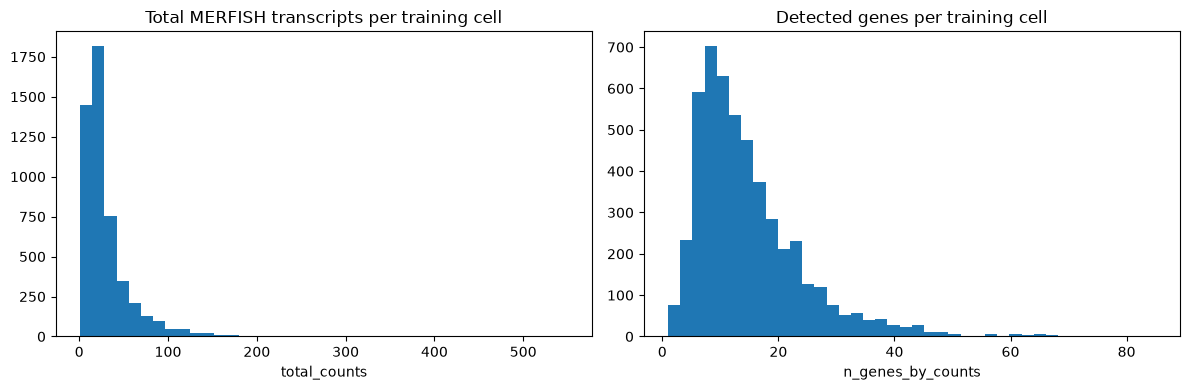

In [143]:
# Create expression matrices

# transform pandas df into numpy matrices
X_train_raw = counts_train[GENE_COLS].to_numpy(dtype=np.float32)
X_test_raw  = counts_test[GENE_COLS].to_numpy(dtype=np.float32)

"""
for each cell add 200 gene counts 
then define true when x_raw>0, else false -> counts the trues
measures overall transcript abundance
"""
qc_train = pd.DataFrame({
    "total_counts": X_train_raw.sum(axis=1),
    "n_genes_by_counts": (X_train_raw > 0).sum(axis=1),
})

qc_test = pd.DataFrame({
    "total_counts": X_test_raw.sum(axis=1),
    "n_genes_by_counts": (X_test_raw > 0).sum(axis=1),
})

display(qc_train.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(qc_train["total_counts"], bins=40)
axes[0].set_title("Total MERFISH transcripts per training cell")
axes[0].set_xlabel("total_counts")

axes[1].hist(qc_train["n_genes_by_counts"], bins=40)
axes[1].set_title("Detected genes per training cell")
axes[1].set_xlabel("n_genes_by_counts")

plt.tight_layout()
plt.show()

This is a sparse, heterogeneous MERFISH dataset\. Most cells contain relatively few transcripts and only a small subset of the 200 measured genes, while a small number of cells contain much higher transcript counts\.

### Preprocessing

Scanpy is used directly on the expression matrix for normalization, \`log1p\`, and PCA\.

The normalized representation is used for exploration and spatial statistics\. The final classifier still uses \`log1p\(raw counts\)\` because that representation validated better for this targeted panel\.

total\-count
normalization is performed directly with NumPy:

\\\[
x'\_\{ij\} =
rac\{x\_\{ij\}\}\{\\sum\_j x\_\{ij\}\} 	imes 10\{,\}000
\\\]

followed by:

\\\[
x''\_\{ij\} = \\log\(1 \+ x'\_\{ij\}\)
\\\]


In [147]:
# total-count normalization with target_sum=1e4.
# Calculate total expression for each cell
cell_totals = X_train_raw.sum(axis=1, keepdims=True).astype(np.float32)

# Protect against division by zero.
cell_totals[cell_totals == 0] = 1.0

X_train_norm = (
    X_train_raw / cell_totals * 1e4
).astype(np.float32)

# log(1 + x)
X_train_norm = np.log1p(X_train_norm).astype(np.float32)

# Scanpy PCA DOES support NumPy arrays directly.
X_train_pca = sc.pp.pca(
    X_train_norm,
    n_comps=30,
    random_state=RANDOM_STATE,
)

print("Normalized expression:", X_train_norm.shape)
print("Scanpy PCA:", X_train_pca.shape)

# Sanity check: non-empty cells should sum to ~10,000 before log1p.
raw_nonempty = X_train_raw.sum(axis=1) > 0
prelog_sums = (
    X_train_raw[raw_nonempty]
    / X_train_raw[raw_nonempty].sum(axis=1, keepdims=True)
    * 1e4
).sum(axis=1)

print(
    "Median normalized total before log1p:",
    float(np.median(prelog_sums)),
)

Normalized expression: (5000, 200)
Scanpy PCA: (5000, 30)
Median normalized total before log1p: 10000.0


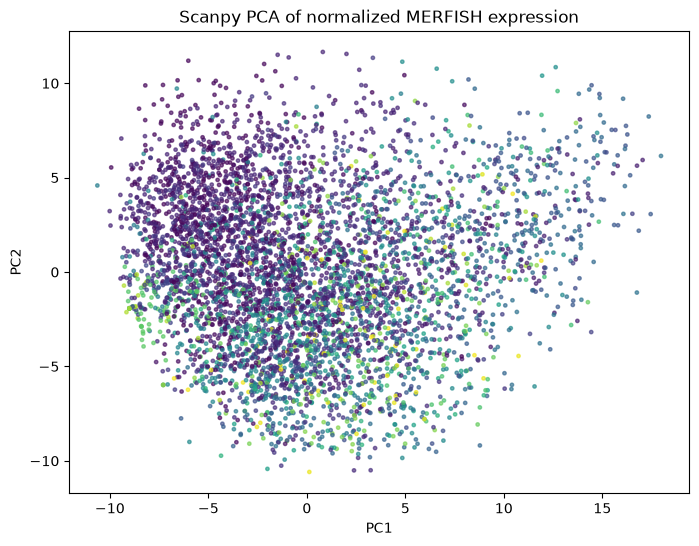

In [149]:
# PCA Visualization
# did not use PCA instead of the 200 genes in the final classifier

label_codes, _ = pd.factorize(meta_train[TARGET].astype(str))

plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=label_codes,
    s=6,
    alpha=0.65,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scanpy PCA of normalized MERFISH expression")
plt.show()

### Gene variability / marker inspection

We inspect gene variance and supervised ANOVA F\-scores, but keep all 200 genes in the final classifier without dropping genes\.

In [153]:
gene_variance = X_train_norm.var(axis=0) # calculate variance for each gene across cells. Highly variable gene may be useful for cell population

variance_table = (
    pd.DataFrame({
        "gene": GENE_COLS,
        "variance": gene_variance,
    })
    .sort_values("variance", ascending=False)
    .reset_index(drop=True)
)

display(variance_table.head(20))

# Anova gene ranking

f_scores, f_pvalues = f_classif(
    np.log1p(X_train_raw),
    meta_train[TARGET].astype(str),
)

marker_table = (
    pd.DataFrame({
        "gene": GENE_COLS,
        "anova_f": f_scores,
        "p_value": f_pvalues,
    })
    .sort_values("anova_f", ascending=False)
    .reset_index(drop=True)
)

display(marker_table.head(20))

,gene,variance
0,Ptgds,13.018474
1,Pvalb,11.004528
2,Sema6d,10.309474
3,Ntrk3,10.289846
4,Grik5,9.453498
5,Adcyap1r1,9.377542
6,Rnf220,8.807926
7,Grid1,8.492540
8,Zfhx3,8.402896
9,Dpy19l1,8.373464


,gene,anova_f,p_value
0,Slc17a7,116.909525,0.0
1,Chat,103.421796,0.0
2,Nmu,89.132735,0.0
3,Tfap2b,88.632477,0.0
4,Shox2,79.541584,0.0
5,Pmp22,74.132247,0.0
6,Slc18a3,69.981345,0.0
7,Pdyn,69.979472,0.0
8,Dnah12,69.506489,0.0
9,Ptgds,62.912744,0.0


### Squidpy spatial KNN graph directly from coordinate arrays

we use Squidpy's public \`KNNBuilder\` directly on \`\(center\_x, center\_y\)\` arrays\.

The graph is built independently inside each \`Section\_ID\`, preventing edges across unrelated tissue sections\.

For final feature engineering, train and test coordinates are combined before graph construction\. No test labels are used\.

In [157]:
# Define a function that creates a spatial neighbor network.


"""
We construct neighbors separately for every tissue section, bcz 

Section A cell: x=100, y=200
Section B cell: x=101, y=201
Numerically they look close.
But physically they came from different sections.
They must not be considered neighbors.

"""


def build_sectionwise_squidpy_knn(meta, n_neighs=6):
    # Build one global sparse KNN graph, section by section.
    meta = meta.reset_index(drop=True)
    n = len(meta)

    adj_rows, adj_cols, adj_data = [], [], []
    dst_rows, dst_cols, dst_data = [], [], []

    for _, index_values in meta.groupby("Section_ID", sort=False).groups.items():
        idx = np.asarray(list(index_values), dtype=int)

        if len(idx) <= 1:
            continue

        coords = meta.loc[idx, ["center_x", "center_y"]].to_numpy(dtype=np.float32)
        k = min(n_neighs, len(idx) - 1)

        builder = KNNBuilder(
            n_neighs=k,
            set_diag=False, # don't connect a cell to itself
        )

        local_adj, local_dst = builder.build(coords)

        a = local_adj.tocoo()
        d = local_dst.tocoo()

        # combine all sections
        adj_rows.append(idx[a.row])
        adj_cols.append(idx[a.col])
        adj_data.append(a.data.astype(np.float32))

        dst_rows.append(idx[d.row])
        dst_cols.append(idx[d.col])
        dst_data.append(d.data.astype(np.float32))

    # constructs one global sparse matrix
    adjacency = coo_matrix(
        (
            np.concatenate(adj_data),
            (np.concatenate(adj_rows), np.concatenate(adj_cols)),
        ),
        shape=(n, n),
        dtype=np.float32,
    ).tocsr()

    distances = coo_matrix(
        (
            np.concatenate(dst_data),
            (np.concatenate(dst_rows), np.concatenate(dst_cols)),
        ),
        shape=(n, n),
        dtype=np.float32,
    ).tocsr()

    adjacency = adjacency.maximum(adjacency.T)
    distances = distances.maximum(distances.T)

    adjacency.setdiag(0)
    distances.setdiag(0)
    adjacency.eliminate_zeros()
    distances.eliminate_zeros()

    return adjacency, distances


meta_all = pd.concat(
    [
        meta_train.assign(_split="train"),
        meta_test.assign(_split="test"),
    ],
    ignore_index=True,
)

spatial_adj_all, spatial_dist_all = build_sectionwise_squidpy_knn(
    meta_all,
    n_neighs=6,
)

print("Spatial adjacency:", spatial_adj_all.shape)
print("Spatial edges:", spatial_adj_all.nnz)

Spatial adjacency: (10000, 10000)
Spatial edges: 73938


### Spatial\-density features from the Squidpy graph

For each cell we derive:
\- spatial degree
\- mean neighbor distance
\- standard deviation of neighbor distance
\- maximum neighbor distance
\- inverse mean distance as a local\-density proxy

In [159]:
def spatial_summary_features(adjacency, distances):
    degree = np.asarray((adjacency > 0).sum(axis=1)).ravel().astype(np.float32)
    safe_degree = np.maximum(degree, 1.0)

    sum_dist = np.asarray(distances.sum(axis=1)).ravel().astype(np.float32)
    mean_dist = sum_dist / safe_degree

    dist_sq = distances.copy()
    dist_sq.data = dist_sq.data ** 2

    sum_sq = np.asarray(dist_sq.sum(axis=1)).ravel().astype(np.float32)

    var_dist = np.maximum(
        (sum_sq / safe_degree) - (mean_dist ** 2),
        0.0,
    )

    std_dist = np.sqrt(var_dist).astype(np.float32)

    max_dist = np.asarray(
        distances.max(axis=1).toarray()
    ).ravel().astype(np.float32)

    inv_mean_dist = 1.0 / (mean_dist + 1e-6)

    return np.column_stack([
        degree,
        mean_dist,
        std_dist,
        max_dist,
        inv_mean_dist,
    ]).astype(np.float32)


spatial_features_all = spatial_summary_features(
    spatial_adj_all,
    spatial_dist_all,
)

n_train = len(meta_train)

spatial_features_train = spatial_features_all[:n_train]
spatial_features_test = spatial_features_all[n_train:]

spatial_feature_names = [
    "spatial_degree",
    "mean_neighbor_distance",
    "std_neighbor_distance",
    "max_neighbor_distance",
    "inverse_mean_neighbor_distance",
]

display(
    pd.DataFrame(
        spatial_features_train,
        columns=spatial_feature_names,
    ).describe()
)

,spatial_degree,mean_neighbor_distance,std_neighbor_distance,max_neighbor_distance,inverse_mean_neighbor_distance
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7.387400,137.486374,52.696087,221.801254,0.008769
std,1.383512,76.483093,37.302528,126.378365,0.003409
min,1.000000,33.288532,0.000000,47.812462,0.001050
25%,6.000000,92.546978,30.988358,142.622734,0.006422
50%,7.000000,117.175571,42.563400,181.959648,0.008534
75%,8.000000,155.712727,62.209165,260.177429,0.010805
max,15.000000,952.700317,572.560303,1448.676636,0.030040


In [163]:
spatial_adj_train = spatial_adj_all[:n_train, :n_train].tocsr()

moran_i = sc.metrics.morans_i(
    spatial_adj_train,
    X_train_norm.T,
)

moran_table = (
    pd.DataFrame({
        "gene": GENE_COLS,
        "morans_I": moran_i,
    })
    .sort_values("morans_I", ascending=False)
    .reset_index(drop=True)
)

display(moran_table.head(20))

,gene,morans_I
0,Pvalb,0.220819
1,Sst,0.219537
2,Nrgn,0.180544
3,Esrrg,0.141440
4,Chat,0.140729
5,Pmp22,0.124349
6,Bnc2,0.107102
7,Slc18a3,0.103854
8,Gad2,0.103210
9,Uts2,0.100133


### Spatial Visualization with Matplotlib

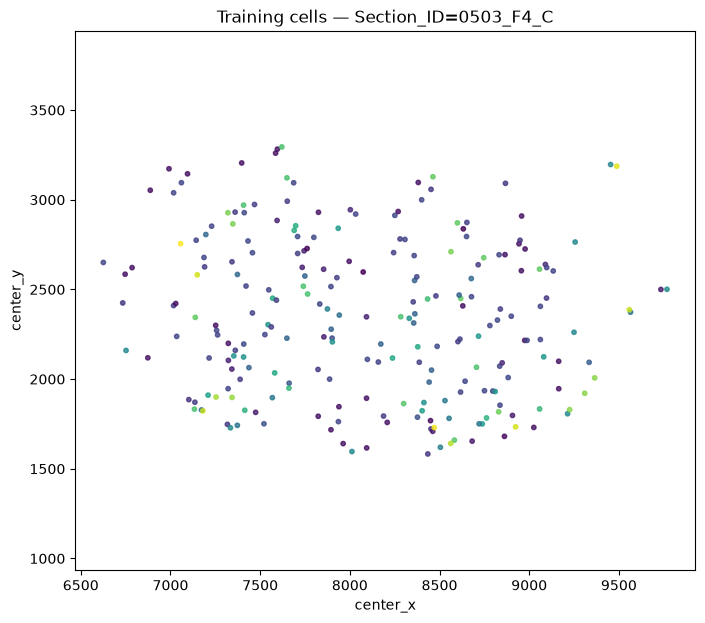

In [165]:
example_section = meta_train["Section_ID"].value_counts().idxmax()
mask = meta_train["Section_ID"] == example_section

section_labels, _ = pd.factorize(
    meta_train.loc[mask, TARGET].astype(str)
)

plt.figure(figsize=(8, 7))
plt.scatter(
    meta_train.loc[mask, "center_x"],
    meta_train.loc[mask, "center_y"],
    c=section_labels,
    s=10,
    alpha=0.8,
)
plt.xlabel("center_x")
plt.ylabel("center_y")
plt.title(f"Training cells — Section_ID={example_section}")
plt.axis("equal")
plt.show()

\#\# Supervised competition features

Final model inputs:

\*\*Expression\*\*
\- all 200 genes
\- \`log1p\(raw counts\)\`

\*\*Categorical metadata\*\*
\- Datasets
\- Region
\- Excitatory\_vs\_Inhibitory
\- Segment
\- Gender
\- Mouse\_ID
\- AP\_position
\- Section\_ID

\*\*Numeric metadata\*\*
\- log cell volume
\- center\_x
\- center\_y
\- total counts
\- detected\-gene count

\*\*Squidpy\-derived spatial features\*\*
\- neighbor\-count and neighbor\-distance summaries

In [167]:

# These are categorical variables supplied in the challenge metadata.

CAT_COLS = [
    "Datasets",
    "Region",
    "Excitatory_vs_Inhibitory",
    "Segment",
    "Gender",
    "Mouse_ID",
    "AP_position",
    "Section_ID",
]

"""
Cell volume can have a skewed distribution.
Log transform prevents very large cells from dominating.
"""
def numeric_meta(counts, meta, spatial_features):
    gene_counts = counts[GENE_COLS].to_numpy(dtype=np.float32)

    basic = np.column_stack([
        np.log1p(meta["volume"].to_numpy(dtype=np.float32)),
        meta["center_x"].to_numpy(dtype=np.float32),
        meta["center_y"].to_numpy(dtype=np.float32),
        gene_counts.sum(axis=1),
        (gene_counts > 0).sum(axis=1),
    ]).astype(np.float32)

    return np.column_stack([
        basic,
        spatial_features,
    ]).astype(np.float32)

"""
We do NOT use X_train_norm here.
We use:
raw counts → log1p
rather than:
normalize total → log1p
Because when we tested normalization earlier, the validation accuracy became worse.

"""
def make_features(
    counts_fit,
    meta_fit,
    spatial_fit,
    counts_apply,
    meta_apply,
    spatial_apply,
):
    g_fit = np.log1p(
        counts_fit[GENE_COLS].to_numpy(dtype=np.float32)
    )

    g_apply = np.log1p(
        counts_apply[GENE_COLS].to_numpy(dtype=np.float32)
    )

    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        dtype=np.float32,
    )

    c_fit = ohe.fit_transform(
        meta_fit[CAT_COLS].fillna("NA").astype(str)
    )

    c_apply = ohe.transform(
        meta_apply[CAT_COLS].fillna("NA").astype(str)
    )

    scaler = StandardScaler()

    n_fit = scaler.fit_transform(
        numeric_meta(counts_fit, meta_fit, spatial_fit)
    ).astype(np.float32)

    n_apply = scaler.transform(
        numeric_meta(counts_apply, meta_apply, spatial_apply)
    ).astype(np.float32)

    x_svc_fit = sparse.hstack(
        [
            sparse.csr_matrix(g_fit),
            c_fit,
            sparse.csr_matrix(n_fit),
        ],
        format="csr",
    )

    x_svc_apply = sparse.hstack(
        [
            sparse.csr_matrix(g_apply),
            c_apply,
            sparse.csr_matrix(n_apply),
        ],
        format="csr",
    )

    x_tree_fit = np.hstack([
        g_fit,
        c_fit.toarray(),
        n_fit,
    ]).astype(np.float32)

    x_tree_apply = np.hstack([
        g_apply,
        c_apply.toarray(),
        n_apply,
    ]).astype(np.float32)

    return x_svc_fit, x_svc_apply, x_tree_fit, x_tree_apply


def blend_predictions(
    svc,
    extra_trees,
    x_svc,
    x_tree,
    temperature=0.35,
    svc_weight=0.50,
):
    assert np.array_equal(
        svc.classes_,
        extra_trees.classes_,
    )

    svc_prob = softmax(
        svc.decision_function(x_svc) / temperature,
        axis=1,
    )

    tree_prob = extra_trees.predict_proba(x_tree)

    blended = (
        svc_weight * svc_prob
        + (1.0 - svc_weight) * tree_prob
    )

    pred = svc.classes_[np.argmax(blended, axis=1)]

    return pred, blended

In [169]:
# held out validation

labels = meta_train[TARGET].astype(str).to_numpy()
indices = np.arange(len(meta_train))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=labels,
)

ct_fit = counts_train.iloc[train_idx].reset_index(drop=True)
mt_fit = meta_train.iloc[train_idx].reset_index(drop=True)
sp_fit = spatial_features_train[train_idx]

ct_val = counts_train.iloc[valid_idx].reset_index(drop=True)
mt_val = meta_train.iloc[valid_idx].reset_index(drop=True)
sp_val = spatial_features_train[valid_idx]

y_fit = mt_fit[TARGET].astype(str).to_numpy()
y_val = mt_val[TARGET].astype(str).to_numpy()

x_svc_fit, x_svc_val, x_tree_fit, x_tree_val = make_features(
    ct_fit,
    mt_fit,
    sp_fit,
    ct_val,
    mt_val,
    sp_val,
)

svc_val = LinearSVC(
    C=0.10,
    dual="auto",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
svc_val.fit(x_svc_fit, y_fit)

et_val = ExtraTreesClassifier(
    n_estimators=250,
    max_features="sqrt",
    min_samples_leaf=1,
    class_weight=None,
    random_state=RANDOM_STATE + 100,
    n_jobs=-1,
)
et_val.fit(x_tree_fit, y_fit)

pred_svc = svc_val.predict(x_svc_val)
pred_et = et_val.predict(x_tree_val)

pred_ensemble, _ = blend_predictions(
    svc_val,
    et_val,
    x_svc_val,
    x_tree_val,
)

print(
    f"LinearSVC validation accuracy: "
    f"{accuracy_score(y_val, pred_svc):.3%}"
)
print(
    f"ExtraTrees validation accuracy: "
    f"{accuracy_score(y_val, pred_et):.3%}"
)
print(
    f"Ensemble validation accuracy:  "
    f"{accuracy_score(y_val, pred_ensemble):.3%}"
)

cm = confusion_matrix(
    y_val,
    pred_ensemble,
    labels=np.sort(np.unique(labels)),
)

print("Confusion matrix shape:", cm.shape)

del x_svc_fit, x_svc_val, x_tree_fit, x_tree_val
del svc_val, et_val
gc.collect()

LinearSVC validation accuracy: 76.100%
ExtraTrees validation accuracy: 74.500%
Ensemble validation accuracy:  76.600%
Confusion matrix shape: (60, 60)
Epoch 197/250:  78%|███████▊  | 196/250 [17:47<04:54,  5.45s/it, v_num=1, train_loss=47.1]


14493

In [171]:
## Fit and train

x_svc_train, x_svc_test, x_tree_train, x_tree_test = make_features(
    counts_train,
    meta_train,
    spatial_features_train,
    counts_test,
    meta_test,
    spatial_features_test,
)

y_train = meta_train[TARGET].astype(str).to_numpy()

svc = LinearSVC(
    C=0.10,
    dual="auto",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
svc.fit(x_svc_train, y_train)

extra_trees = ExtraTreesClassifier(
    n_estimators=350,
    max_features="sqrt",
    min_samples_leaf=1,
    class_weight=None,
    random_state=RANDOM_STATE + 100,
    n_jobs=-1,
)
extra_trees.fit(x_tree_train, y_train)

test_pred, test_probability = blend_predictions(
    svc,
    extra_trees,
    x_svc_test,
    x_tree_test,
)

print("Predicted test cells:", len(test_pred))
print("Distinct predicted labels:", len(np.unique(test_pred)))

Predicted test cells: 5000
Distinct predicted labels: 57


In [175]:
## This is to get the prediction scores to see which 
# model ran better for submission

# Need the index of the predicted class for each cell
predicted_class_i = np.argmax(test_probability, axis = 1)

# Then we need the pribability assigned to the predicted class for the confidence score
prediction_confidence = test_probability[
    np.arange(len(test_probability)),
    predicted_class_i
]

print(prediction_confidence.mean())
print(prediction_confidence.min())
print(prediction_confidence.max())
print(prediction_confidence)

0.5779768245408837
0.11533956319788036
0.9702536157460149
[0.77610394 0.47405267 0.82901117 ... 0.80876027 0.671865   0.26140274]


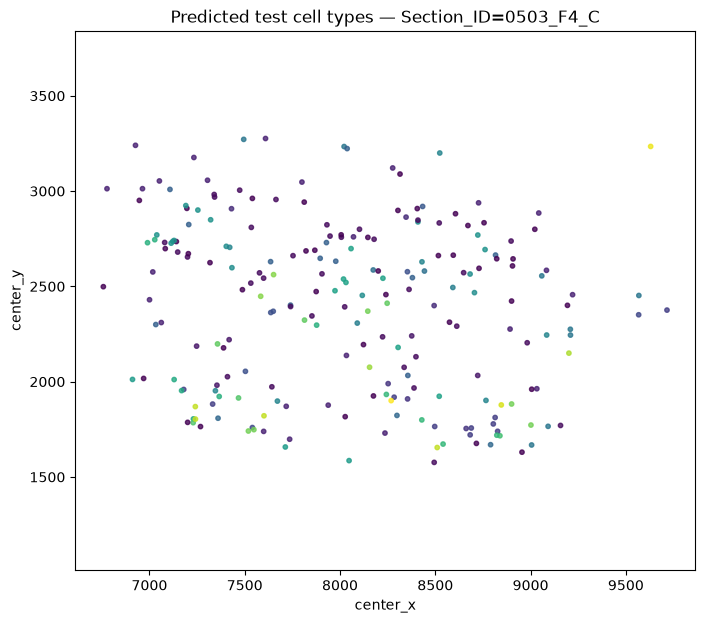

In [177]:
test_section = meta_test["Section_ID"].value_counts().idxmax()
mask_test = meta_test["Section_ID"] == test_section

test_label_codes, _ = pd.factorize(
    pd.Series(test_pred)[mask_test.to_numpy()]
)

plt.figure(figsize=(8, 7))
plt.scatter(
    meta_test.loc[mask_test, "center_x"],
    meta_test.loc[mask_test, "center_y"],
    c=test_label_codes,
    s=10,
    alpha=0.8,
)
plt.xlabel("center_x")
plt.ylabel("center_y")
plt.title(f"Predicted test cell types — Section_ID={test_section}")
plt.axis("equal")
plt.show()

### Write prediction csv file

In [183]:
submission = pd.DataFrame({
    "Cell_ID": meta_test[ID_COL].astype(str).to_numpy(),
    "MERFISH_cell_type_annotation.y": test_pred,
    "prediction_confidence": prediction_confidence
})

allowed_labels = set(
    meta_train[TARGET].astype(str).unique()
)

assert len(submission) == len(meta_test)
assert submission["Cell_ID"].tolist() == meta_test[ID_COL].astype(str).tolist()
assert submission["Cell_ID"].map(type).eq(str).all()
assert set(
    submission["MERFISH_cell_type_annotation.y"]
).issubset(allowed_labels)
assert submission.isna().sum().sum() == 0

OUTPUT = "prediction.csv"

submission.to_csv(
    OUTPUT,
    index=False,
    quoting=csv.QUOTE_ALL,
)

print("Saved:", OUTPUT)
print("Shape:", submission.shape)
display(submission.head(10))

Saved: prediction.csv
Shape: (5000, 3)


,Cell_ID,MERFISH_cell_type_annotation.y,prediction_confidence
0,2796212800954100068,DH_ex_Grpr,0.776104
1,2707604000123100074,oligodendrocyte_progenitor_2,0.474053
2,2796212800080100088,astrocyte_1,0.829011
3,2946331700000000970,oligodendrocyte_2,0.902632
4,2796212800882100299,DH_in_Rorb,0.761901
5,2787889600415100083,astrocyte_1,0.809602
6,2795903600185100289,oligodendrocyte_progenitor_2,0.572713
7,2707737900071100040,astrocyte_1,0.634997
8,2707604800079100103,oligodendrocyte_progenitor_2,0.230464
9,2946331700000004334,DH_ex_Reln/Npff,0.749953


In [185]:
display(submission)

,Cell_ID,MERFISH_cell_type_annotation.y,prediction_confidence
0,2796212800954100068,DH_ex_Grpr,0.776104
1,2707604000123100074,oligodendrocyte_progenitor_2,0.474053
2,2796212800080100088,astrocyte_1,0.829011
3,2946331700000000970,oligodendrocyte_2,0.902632
4,2796212800882100299,DH_in_Rorb,0.761901
...,...,...,...
4995,2787889600409100230,endothelial,0.406339
4996,2795584800388100027,astrocyte_1,0.199946
4997,2656143800130100146,astrocyte_1,0.808760
4998,2707604700272100140,oligodendrocyte_progenitor_2,0.671865


In [187]:
submission.to_csv('tasmia_prediction.csv', index=False)

### Confidence\-Prediction Scores Section

<function matplotlib.pyplot.show(close=None, block=None)>

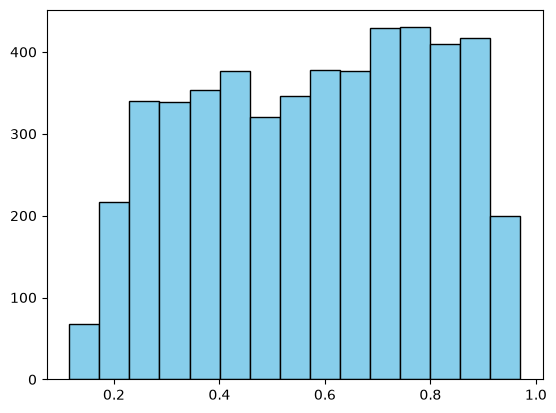

In [201]:
plt.hist(prediction_confidence, bins = 15, color="skyblue", edgecolor="black")
plt.show

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=455d92ce-61c0-4f15-b27b-1ef3d91a99f7' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>